In [1]:
import sys, os

## Include previous level directories to the module import path
sys.path.insert(0, os.path.abspath(os.path.join("..")))

# import arviz as az
import numpy as np
import h5py

# Export the results to GetDist

# Notice loadMCSamples requires a *full path*
import os
from matplotlib import pyplot as plt
import matplotlib

from matplotlib import cm

matplotlib.rcParams.update(
    {
        "font.size": 16,
        "axes.labelsize": 24,
        "axes.titlesize": 18,
        "text.usetex": True,
        "xtick.major.width": 1.5,
        "xtick.minor.width": 1.2,
        "ytick.major.width": 1.5,
        "ytick.minor.width": 1.2,
        "legend.fontsize": 18,
    }
)

# Deep purples / indigos
c_flatirons = "#440154"
c_flatirons_l = "#472d7b"
c_flatirons_ll = "#3b528b"

# Teal / cyan region
c_sunshine = "#2a788e"
c_sunshine_l = "#21908d"
c_sunshine_ll = "#20a386"

# Green-cyan (maximum brightness allowed)
c_skyline = "#35b779"
c_skyline_l = "#5ec962"  # Cap brightness here
# c_skyline_ll = omitted due to low print contrast

# Blue highlight
c_midnight = "#31688e"


cmap = cm.get_cmap("viridis")

# change fontsize
matplotlib.rcParams.update(
    {"font.size": 12, "axes.labelsize": 16, "axes.titlesize": 14}
)

# matplotlib.use('PDF')
save_figure = lambda filename: plt.savefig(
    "{}.pdf".format(filename), format="pdf", dpi=300
)

outfile = "../cddf_all/"


/var/folders/sn/b7hd1bmd569cjwgmtww4mv440000gn/T/ipykernel_83783/702180666.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


## From Reza CIV catalog to CDDF

In [2]:
import h5py, pandas as pd

In [3]:
# Just the catalog, without the NCIV zCIV uncertainty
with h5py.File("../../CIVDR16/processed_qsos_dr16_parameters.mat", "r") as f:
    # <KeysViewHDF5 ['all_REW_1548_dr12', 'all_log_likelihoods_c4L2', 'all_log_likelihoods_no_c4', 'all_log_posteriors_c4L1', 'all_log_posteriors_c4L2', 'all_log_posteriors_no_c4', 'all_log_priors_c4', 'all_log_priors_no_c4', 'all_map_N_c4L1', 'all_map_N_c4L2', 'all_map_sigma_c4L1', 'all_map_sigma_c4L2', 'all_map_z_c4L1', 'all_map_z_c4L2', 'all_max_z_c4s', 'all_min_z_c4s', 'all_p_c4', 'all_p_c4L1', 'all_p_no_c4', 'test_ind']>
    print(f['savingCat'].keys())
    # redshift bins
    z_civ = f['savingCat']['all_map_z_c4L2'][:]
    # column density bins
    n_civ = f['savingCat']['all_map_N_c4L2'][:]
    ew_civ = f['savingCat']['all_REW_1548_dr12'][:]
    # search limits
    z_maxs = f['savingCat']['all_max_z_c4s'][:]
    z_mins = f['savingCat']['all_min_z_c4s'][:]
    # probabilities
    p_civ = f['savingCat']['all_p_c4'][:]


    test_ind = f['savingCat']['test_ind'][:].astype(bool)

<KeysViewHDF5 ['all_REW_1548_dr12', 'all_log_likelihoods_c4L2', 'all_log_likelihoods_no_c4', 'all_log_posteriors_c4L1', 'all_log_posteriors_c4L2', 'all_log_posteriors_no_c4', 'all_log_priors_c4', 'all_log_priors_no_c4', 'all_map_N_c4L1', 'all_map_N_c4L2', 'all_map_sigma_c4L1', 'all_map_sigma_c4L2', 'all_map_z_c4L1', 'all_map_z_c4L2', 'all_max_z_c4s', 'all_min_z_c4s', 'all_p_c4', 'all_p_c4L1', 'all_p_no_c4', 'test_ind']>


In [4]:
# repeat this seven times to match (7, N_qso)
_N = z_civ.shape[0]
z_maxs_N = np.repeat(z_maxs.T, _N, axis=1)
z_mins_N = np.repeat(z_mins.T, _N, axis=1)
test_ids = np.repeat(np.where(test_ind)[1][:, None], _N, axis=1)

# check
print(z_maxs_N.shape, z_mins_N.shape, test_ids.shape)

# make pandas dataframe
civ_data = pd.DataFrame({
    'Z': z_civ.T.flatten(), # (7, 250983) -> (250983, 7) -> (250983*7,)
    'logN': n_civ.T.flatten(),
    'p_CIV': p_civ.T.flatten(),
    # 'sigma_Z': sigma_z_civ.T.flatten(),
    # 'sigma_logN': sigma_n_civ.T.flatten(),
    'z_max': z_maxs_N.flatten(),
    'z_min': z_mins_N.flatten(),
    'test_ids': test_ids.flatten(),
})

(250983, 7) (250983, 7) (250983, 7)


Number of detections with P_CIV > 0.5: 272338
Number of detections with P_CIV > 0.549: 238798
Number of detections with P_CIV > 0.598: 209004
Number of detections with P_CIV > 0.647: 181833
Number of detections with P_CIV > 0.696: 159297
Number of detections with P_CIV > 0.745: 145481
Number of detections with P_CIV > 0.794: 136963
Number of detections with P_CIV > 0.843: 128903
Number of detections with P_CIV > 0.892: 120361
Number of detections with P_CIV > 0.9410000000000001: 109650
Number of detections with P_CIV > 0.99: 87082


Text(0.5, 1.0, 'Number of CIV detections vs P_CIV threshold')

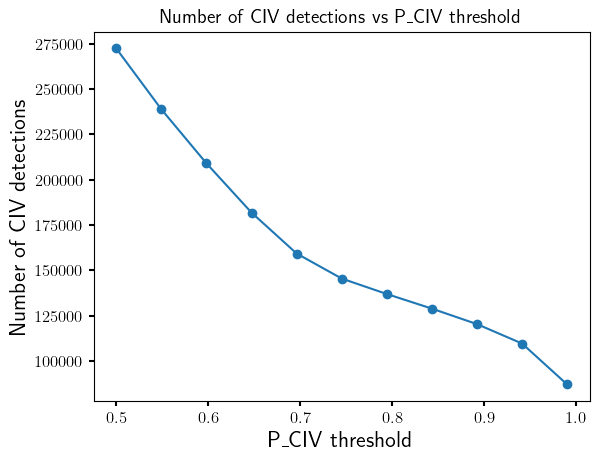

In [5]:
# number of detection with P_CIV > ?
p_thresholds = np.linspace(0.5, 0.99, 11)

N_det = []

for p in p_thresholds:
    ind = civ_data["p_CIV"] > p
    print(f"Number of detections with P_CIV > {p}: {np.sum(ind)}")
    N_det.append(np.sum(ind))

plt.plot(p_thresholds, N_det, marker='o')
plt.xlabel("P_CIV threshold")
plt.ylabel("Number of CIV detections")
plt.title("Number of CIV detections vs P_CIV threshold")
# save_figure(os.path.join(outfile, "CIV_detections_vs_pCIV_threshold"))

In [6]:
ind = civ_data["p_CIV"] > 0.80
civ_det_data = civ_data[ind]
civ_det_data

,Z,logN,p_CIV,z_max,z_min,test_ids
22,1.929981,13.747034,0.980027,1.961379,1.541097,8
23,1.788639,14.028159,0.952180,1.961379,1.541097,8
24,1.819575,13.956493,0.850873,1.961379,1.541097,8
50,1.680711,14.768234,0.949711,2.051898,1.618463,24
70,3.333291,14.466678,0.989727,3.663857,2.996204,28
...,...,...,...,...,...,...
1756853,1.725981,14.241508,0.999638,2.172928,1.721907,750405
1756868,2.641167,14.351475,0.972346,3.067882,2.486824,750410
1756869,2.930561,14.392619,0.999686,3.067882,2.486824,750410
1756870,2.784233,14.179269,0.998910,3.067882,2.486824,750410


## CDDF

In [7]:
#!/usr/bin/env python3
# ============================================================
# CIV CDDF summary statistics: f(N) = d^2 N_abs / (dN dX)
#
# Bird+ convention (same as your DLA code):
#   f(N) = d^2 N_abs / (dN dX)
# where N is LINEAR column density in cm^-2, X is dimensionless absorption distance.
#
# This script assumes you have a pandas DataFrame with columns:
#   Z        : absorber redshift
#   logN     : log10 column density (e.g. log10 N_CIV / cm^-2)
#   p_CIV    : detection probability (USED ONLY for thresholding)
#   z_min    : search window minimum for that sightline
#   z_max    : search window maximum for that sightline
#   test_ids : unique sightline id (same for absorbers on the same quasar)
#
# Critical: dX must be computed ONCE PER SIGHTLINE (test_ids), not per absorber row.
# ============================================================

from __future__ import annotations

import numpy as np
import pandas as pd

# ----------------------------
# 1) Cosmology / path length
# ----------------------------
C_KMS = 299792.458

def HubbleByH0(z, Omega_m=0.279):
    """
    H(z)/H0 for flat LCDM with Omega_m, Omega_L = 1 - Omega_m
    """
    z = np.asarray(z, dtype=float)
    return np.sqrt(Omega_m * (1.0 + z) ** 3 + (1.0 - Omega_m))


def path_length_int(z, Omega_m=0.279):
    """
    dX/dz = (1+z)^2 / (H(z)/H0)
    """
    z = np.asarray(z, dtype=float)
    return (1.0 + z) ** 2 / HubbleByH0(z, Omega_m)


class AbsorptionDistance:
    """
    Fast helper to compute X(z)=∫ dX/dz dz and ΔX via grid + interpolation.
    Uses trapezoidal integration on a fixed grid.
    """
    def __init__(self, zmax, Omega_m=0.279, ngrid=40001):
        self.Omega_m = float(Omega_m)
        self.zgrid = np.linspace(0.0, float(zmax), int(ngrid))
        integrand = path_length_int(self.zgrid, Omega_m=self.Omega_m)

        dz = np.diff(self.zgrid)
        X = np.empty_like(self.zgrid)
        X[0] = 0.0
        X[1:] = np.cumsum(0.5 * (integrand[:-1] + integrand[1:]) * dz)
        self.Xgrid = X

    def X(self, z):
        z = np.asarray(z, dtype=float)
        return np.interp(z, self.zgrid, self.Xgrid)

    def deltaX(self, z1, z2):
        z1 = np.asarray(z1, dtype=float)
        z2 = np.asarray(z2, dtype=float)
        return self.X(z2) - self.X(z1)


def total_DeltaX_in_zbins(zbins, sight_zlo, sight_zhi, Xcalc):
    """
    ΔX_k = sum_i ∫_{W_i ∩ [z_k,z_{k+1}]} dX   over UNIQUE sightlines.
    """
    zbins = np.asarray(zbins, dtype=float)
    nb = len(zbins) - 1
    X_tot = np.zeros(nb, dtype=float)

    for k in range(nb):
        lo, hi = zbins[k], zbins[k + 1]
        o_lo = np.maximum(sight_zlo, lo)
        o_hi = np.minimum(sight_zhi, hi)
        m = o_hi > o_lo
        if np.any(m):
            X_tot[k] = np.sum(Xcalc.deltaX(o_lo[m], o_hi[m]))
    return X_tot


# ----------------------------
# 2) CIV CDDF computation
# ----------------------------

def compute_civ_cddf_fN_from_df(
    civ_df: pd.DataFrame,
    *,
    zbins,
    logN_bins,
    id_col="test_ids",
    z_col="Z",
    logN_col="logN",
    p_col="p_CIV",
    zmin_col="z_min",
    zmax_col="z_max",
    p_thresh=0.99,
    Omega_m=0.279,
    logNmin=None,
    logNmax=None,
    n_boot=0,
    rng=None,
    # if your z_min/z_max are float-noisy, set rounding like 6 or 7
    round_window_decimals=None,
):
    """
    Compute CDDF in Bird+ convention:
        f(N) = d^2 N_abs / (dN dX)
    using log10N bins but dividing by ΔN (linear).

    Key points:
      - ΔX is computed from UNIQUE sightlines (id_col).
      - p_CIV is used ONLY as a detection threshold.
      - bootstrap resamples sightlines (ids), not absorbers.

    Returns dict with fN, err_poisson, err_boot, counts, X_tot, etc.
    """
    zbins = np.asarray(zbins, dtype=float)
    logN_bins = np.asarray(logN_bins, dtype=float)

    z_mid = 0.5 * (zbins[:-1] + zbins[1:])
    nbz = len(z_mid)
    nbn = len(logN_bins) - 1

    # Linear bin edges and widths ΔN (cm^-2)
    N_edges = 10.0 ** logN_bins
    dN = np.diff(N_edges)  # (nbn,)

    # Geometric-mean bin center (standard for log bins)
    N_mid = np.sqrt(N_edges[:-1] * N_edges[1:])
    logN_mid = np.log10(N_mid)

    # Optional rounding if windows are float-noisy
    if round_window_decimals is not None:
        civ_df = civ_df.copy()
        civ_df[zmin_col] = civ_df[zmin_col].round(int(round_window_decimals))
        civ_df[zmax_col] = civ_df[zmax_col].round(int(round_window_decimals))

    # ---- (A) Build UNIQUE sightlines from id_col
    # Take one row per id to define the search window.
    sight = civ_df[[id_col, zmin_col, zmax_col]].dropna().drop_duplicates(subset=[id_col])

    sight_ids = sight[id_col].to_numpy()
    sight_zlo = sight[zmin_col].to_numpy(dtype=float)
    sight_zhi = sight[zmax_col].to_numpy(dtype=float)

    good = np.isfinite(sight_zlo) & np.isfinite(sight_zhi) & (sight_zhi > sight_zlo)
    sight_ids = sight_ids[good]
    sight_zlo = sight_zlo[good]
    sight_zhi = sight_zhi[good]

    nsight = len(sight_ids)
    if nsight == 0:
        raise ValueError("No valid sightlines: require finite z_min/z_max and z_max > z_min.")

    # Map id -> [0..nsight-1]
    id_to_idx = {sid: i for i, sid in enumerate(sight_ids)}

    # ---- (B) Compute ΔX per z-bin from unique sightlines
    Xcalc = AbsorptionDistance(zmax=float(np.max(sight_zhi)), Omega_m=Omega_m)
    X_tot = total_DeltaX_in_zbins(zbins, sight_zlo, sight_zhi, Xcalc)

    # ---- (C) Filter absorbers by p-threshold (+ optional logN cuts)
    z_abs = civ_df[z_col].to_numpy(dtype=float)
    logN = civ_df[logN_col].to_numpy(dtype=float)
    p = civ_df[p_col].to_numpy(dtype=float)
    sid = civ_df[id_col].to_numpy()

    ok = np.isfinite(z_abs) & np.isfinite(logN) & np.isfinite(p)
    ok &= (p >= float(p_thresh))

    if logNmin is not None:
        ok &= (logN >= float(logNmin))
    if logNmax is not None:
        ok &= (logN <= float(logNmax))

    z_abs = z_abs[ok]
    logN = logN[ok]
    sid = sid[ok]

    # Keep only absorbers whose sightline id survived window validation
    keep = np.fromiter((s in id_to_idx for s in sid), dtype=bool, count=len(sid))
    z_abs = z_abs[keep]
    logN = logN[keep]
    sid = sid[keep]

    sight_idx_abs = np.fromiter((id_to_idx[s] for s in sid), dtype=int, count=len(sid))

    # ---- (D) Bin absorbers into (zbin, nbin)
    zbin = np.digitize(z_abs, zbins) - 1
    nbin = np.digitize(logN, logN_bins) - 1
    valid = (zbin >= 0) & (zbin < nbz) & (nbin >= 0) & (nbin < nbn)

    zbin = zbin[valid]
    nbin = nbin[valid]
    sight_idx_abs = sight_idx_abs[valid]

    counts = np.zeros((nbz, nbn), dtype=int)
    np.add.at(counts, (zbin, nbin), 1)

    # Normalize: f(N) = counts / (ΔX * ΔN)
    fN = np.full((nbz, nbn), np.nan, dtype=float)
    err_pois = np.full((nbz, nbn), np.nan, dtype=float)
    for k in range(nbz):
        if X_tot[k] > 0:
            fN[k] = counts[k] / (X_tot[k] * dN)
            err_pois[k] = np.sqrt(counts[k]) / (X_tot[k] * dN)

    # ---- (E) Bootstrap over sightlines
    err_boot = None
    if n_boot and n_boot > 0:
        rng = np.random.default_rng() if rng is None else rng

        # per-sightline ΔX contributions in each zbin
        per_sight_X = np.zeros((nsight, nbz), dtype=float)
        for k in range(nbz):
            lo, hi = zbins[k], zbins[k + 1]
            o_lo = np.maximum(sight_zlo, lo)
            o_hi = np.minimum(sight_zhi, hi)
            m = o_hi > o_lo
            if np.any(m):
                per_sight_X[m, k] = Xcalc.deltaX(o_lo[m], o_hi[m])

        # per-sightline 2D counts
        per_sight_counts = np.zeros((nsight, nbz, nbn), dtype=int)
        np.add.at(per_sight_counts, (sight_idx_abs, zbin, nbin), 1)

        boot = np.empty((n_boot, nbz, nbn), dtype=float)
        for b in range(n_boot):
            draw = rng.integers(0, nsight, size=nsight)  # resample sightlines w/ replacement
            Cb = per_sight_counts[draw].sum(axis=0)
            Xb = per_sight_X[draw].sum(axis=0)

            fb = np.full((nbz, nbn), np.nan, dtype=float)
            for k in range(nbz):
                if Xb[k] > 0:
                    fb[k] = Cb[k] / (Xb[k] * dN)
            boot[b] = fb

        err_boot = np.nanstd(boot, axis=0, ddof=1)

    return {
        "z_mid": z_mid,
        "zbins": zbins,
        "logN_mid": logN_mid,
        "logN_bins": logN_bins,
        "N_mid": N_mid,
        "N_edges": N_edges,
        "dN": dN,
        "fN": fN,
        "err_poisson": err_pois,
        "err_boot": err_boot,
        "counts": counts,
        "X_tot": X_tot,
        "nsight": nsight,
        "meta": {
            "Omega_m": float(Omega_m),
            "p_thresh": float(p_thresh),
            "logNmin": None if logNmin is None else float(logNmin),
            "logNmax": None if logNmax is None else float(logNmax),
        },
    }


# ----------------------------
# 3) Example usage
# # ----------------------------
# if __name__ == "__main__":
#     # Example: civ_df already in memory as a pandas DataFrame
#     # If you need to read it:
#     # civ_df = pd.read_parquet("civ_catalog.parquet")
#     # civ_df = pd.read_csv("civ_catalog.csv")  # must contain the required columns

#     # Minimal toy example (replace with your real civ_df)
#     civ_df = pd.DataFrame({
#         "Z":      [1.986074, 2.125348, 1.604026, 2.488643, 2.782393],
#         "logN":   [14.298362, 14.089500, 14.771092, 14.292976, 14.127203],
#         "p_CIV":  [1.0, 1.0, 1.0, 0.999929, 0.999116],
#         "z_max":  [2.148178, 2.148178, 1.822861, 2.792663, 2.792663],
#         "z_min":  [1.700753, 1.700753, 1.422705, 2.251595, 2.251595],
#         "test_ids":[62, 62, 69, 126, 126],
#     })

#     # Define binning
#     zbins = np.arange(1.4, 3.2 + 1e-9, 0.2)           # z bins
#     logN_bins = np.arange(13.0, 15.5 + 1e-9, 0.2)     # logN bins

#     out = compute_civ_cddf_fN_from_df(
#         civ_df,
#         zbins=zbins,
#         logN_bins=logN_bins,
#         p_thresh=0.99,       # hard threshold (no weighting)
#         Omega_m=0.279,
#         logNmin=None,
#         logNmax=None,
#         n_boot=200,          # bootstrap over sightlines
#         rng=np.random.default_rng(1234),
#         round_window_decimals=None,  # set to e.g. 6 if needed
#     )

#     # Example: inspect outputs
#     print("nsight =", out["nsight"])
#     print("z_mid shape:", out["z_mid"].shape)
#     print("logN_mid shape:", out["logN_mid"].shape)
#     print("fN shape:", out["fN"].shape)
#     print("err_boot is None?", out["err_boot"] is None)

#     # Example: get CDDF at one redshift bin index k
#     k = 3
#     fN_k = out["fN"][k]
#     eN_k = out["err_boot"][k] if out["err_boot"] is not None else out["err_poisson"][k]
#     print(f"Example z-bin k={k}, z~{out['z_mid'][k]:.3f}")
#     print("logN_mid:", out["logN_mid"])
#     print("fN:", fN_k)
#     print("err:", eN_k)

Plottings

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plotting utilities for CIV dN/dX + CDDF outputs
# (match your DLA plotting style; just relabel to CIV)
# ============================================================

def plot_civ_dndx(out, *, label=None, prefer_boot=True, ax=None, show=True, color=None):
    """
    out = output dict from compute_civ_dndx_from_df(...)
    """
    z = out["z_mid"]
    y = out["dndx"]
    yerr = out["err_boot"] if (prefer_boot and out.get("err_boot") is not None) else out["err_poisson"]

    zb = out["zbins"]
    xerr = 0.5 * (zb[1:] - zb[:-1])

    if ax is None:
        fig, ax = plt.subplots()

    ax.errorbar(z, y, yerr=yerr, xerr=xerr, fmt="o", capsize=2, label=label, color=color)
    ax.set_xlabel("z")
    ax.set_ylabel(r"$dN_{\rm CIV}/dX$")
    ax.grid(True, alpha=0.3)
    if label:
        ax.legend()
    if show:
        plt.show()
    return ax


def plot_civ_cddf_slice_fN(out, zbin_index, *, label=None, prefer_boot=True, ax=None, show=True, ylog=True, color=None):
    """
    Plot f(N) vs log10 N at a chosen z-bin index.
    out = output dict from compute_civ_cddf_fN_from_df(...)
    """
    x = out["logN_mid"]
    y = out["fN"][zbin_index]
    yerr = out["err_boot"][zbin_index] if (prefer_boot and out.get("err_boot") is not None) else out["err_poisson"][zbin_index]

    if ax is None:
        fig, ax = plt.subplots()

    ax.errorbar(x, y, yerr=yerr, fmt="o", capsize=2, label=label, color=color)
    ax.set_xlabel(r"$\log_{10} N_{\rm CIV}$")
    ax.set_ylabel(r"$f(N)=d^2N/(dN\,dX)$  [cm$^2$]")
    ax.grid(True, alpha=0.3)
    if ylog:
        ax.set_yscale("log")
    if label:
        ax.legend()
    if show:
        plt.show()
    return ax


def plot_civ_cddf_grid(out, *, ax=None, show=True, vmin=None, vmax=None):
    """
    Heatmap of log10 f(N,z).
    Useful to quickly see coverage and any "holes" from binning.
    """
    zb = out["zbins"]
    logNb = out["logN_bins"]
    fN = out["fN"]

    # log10 with masking
    img = np.log10(np.where(np.isfinite(fN) & (fN > 0), fN, np.nan))

    if ax is None:
        fig, ax = plt.subplots()

    # pcolormesh expects (ny, nx) for C with edges arrays
    m = ax.pcolormesh(logNb, zb, img, shading="auto", vmin=vmin, vmax=vmax)
    cb = plt.colorbar(m, ax=ax)
    cb.set_label(r"$\log_{10} f(N)$")

    ax.set_xlabel(r"$\log_{10} N_{\rm CIV}$")
    ax.set_ylabel("z")
    ax.set_title("CIV CDDF grid")
    if show:
        plt.show()
    return ax


def plot_civ_dndx_and_cddf(out_dndx, out_cddf, zbin_index, *, label=None, prefer_boot=True, show=True):
    """
    Convenience: one figure with dN/dX (left) and one CDDF slice (right).
    """
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    plot_civ_dndx(out_dndx, label=label, prefer_boot=prefer_boot, ax=axs[0], show=False)
    plot_civ_cddf_slice_fN(out_cddf, zbin_index, label=label, prefer_boot=prefer_boot, ax=axs[1], show=False, ylog=True)
    if show:
        plt.show()
    return axs


# ============================================================
# Optional: Omega_CIV from CDDF (analogue of your Omega_HI)
# ============================================================

def omega_species_prefactor(m_amu, *, H0_km_s_Mpc=70.0):
    """
    Generalization of your omega_hi_prefactor:
      K = H0 * m_species / (c * rho_c0)
    where m_species is mass per absorber particle in grams.
    For CIV you'd decide what "mass" you want:
      - Carbon mass (12 amu)
      - or ion mass ~ carbon mass (electron negligible)
    """
    # cgs
    c_cms = 2.99792458e10
    G_cgs = 6.67430e-8

    # atomic mass unit (g)
    amu_g = 1.66053906660e-24
    m_g = m_amu * amu_g

    # H0 in s^-1
    Mpc_cm = 3.085677581e24
    H0_s = (H0_km_s_Mpc * 1.0e5) / Mpc_cm

    # rho_c0
    rho_c0 = 3.0 * H0_s**2 / (8.0 * np.pi * G_cgs)

    K = (H0_s * m_g) / (c_cms * rho_c0)
    return K


def omega_from_cddf(
    out_cddf,
    *,
    m_amu,
    zbin_index=None,
    zmin=None,
    zmax=None,
    logN_min=None,
    logN_max=None,
    H0_km_s_Mpc=70.0,
    prefer_boot=True,
):
    """
    Omega_species(z) = K * ∫ N f(N,z) dN
    Same structure as your omega_hi_from_cddf.
    """
    z_mid = np.asarray(out_cddf["z_mid"], float)
    N_edges = np.asarray(out_cddf["N_edges"], float)
    dN = np.asarray(out_cddf["dN"], float)
    fN = np.asarray(out_cddf["fN"], float)

    if prefer_boot and (out_cddf.get("err_boot") is not None):
        fN_err = np.asarray(out_cddf["err_boot"], float)
        err_kind = "boot"
    else:
        fN_err = np.asarray(out_cddf["err_poisson"], float)
        err_kind = "poisson"

    logN_edges = np.log10(N_edges)
    n_lo = 0 if (logN_min is None) else int(np.searchsorted(logN_edges, logN_min, side="left"))
    n_hi = len(dN) if (logN_max is None) else int(np.searchsorted(logN_edges, logN_max, side="right") - 1)
    n_lo = max(0, min(n_lo, len(dN)))
    n_hi = max(0, min(n_hi, len(dN)))
    if n_hi <= n_lo:
        raise ValueError("Empty N range after applying logN_min/logN_max.")

    N_mid = np.sqrt(N_edges[:-1] * N_edges[1:])
    K = omega_species_prefactor(m_amu, H0_km_s_Mpc=H0_km_s_Mpc)

    if zbin_index is not None:
        z_sel = np.array([z_mid[int(zbin_index)]])
        f_sel = fN[int(zbin_index)][None, :]
        e_sel = fN_err[int(zbin_index)][None, :]
    else:
        m = np.ones_like(z_mid, dtype=bool)
        if zmin is not None:
            m &= (z_mid >= float(zmin))
        if zmax is not None:
            m &= (z_mid <= float(zmax))
        z_sel = z_mid[m]
        f_sel = fN[m]
        e_sel = fN_err[m]
        if len(z_sel) == 0:
            raise ValueError("No z-bins selected.")

    Nm = N_mid[n_lo:n_hi]
    dNj = dN[n_lo:n_hi]

    omega = K * np.sum((Nm * f_sel[:, n_lo:n_hi]) * dNj[None, :], axis=1)
    omega_err = K * np.sqrt(np.sum(((Nm * e_sel[:, n_lo:n_hi]) * dNj[None, :])**2, axis=1))

    return {
        "z": z_sel,
        "omega": omega,
        "omega_err": omega_err,
        "meta": {
            "m_amu": float(m_amu),
            "H0_km_s_Mpc": float(H0_km_s_Mpc),
            "err_kind": err_kind,
            "logN_min": None if logN_min is None else float(logN_min),
            "logN_max": None if logN_max is None else float(logN_max),
        },
    }


def plot_omega(out_omega, *, ax=None, label=None, show=True, scale=1e8):
    """
    Generic Omega plot with a convenient scaling for visualization.
    Default scale=1e8 is arbitrary; change as you like.
    """
    z = out_omega["z"]
    y = scale * out_omega["omega"]
    yerr = scale * out_omega["omega_err"]

    if ax is None:
        fig, ax = plt.subplots()

    ax.errorbar(z, y, yerr=yerr, fmt="o", capsize=2, label=label)
    ax.set_xlabel("z")
    ax.set_ylabel(fr"${scale:.0e}\,\Omega$")
    ax.grid(True, alpha=0.3)
    if label:
        ax.legend()
    if show:
        plt.show()
    return ax


# ============================================================
# Example usage (assumes you already computed out_dndx/out_cddf)
# ============================================================
#
# out_dndx = compute_civ_dndx_from_df(civ_df, zbins=..., p_thresh=..., n_boot=200, ...)
# out_cddf = compute_civ_cddf_fN_from_df(civ_df, zbins=..., logN_bins=..., p_thresh=..., n_boot=200, ...)
#
# plot_civ_dndx(out_dndx, label="CIV, p>=0.99", prefer_boot=True)
# plot_civ_cddf_slice_fN(out_cddf, zbin_index=3, label="CIV, p>=0.99", prefer_boot=True)
# plot_civ_cddf_grid(out_cddf)
# plot_civ_dndx_and_cddf(out_dndx, out_cddf, zbin_index=3, label="CIV", prefer_boot=True)
#
# out_omegaC = omega_from_cddf(out_cddf, m_amu=12.0, logN_min=13.0, logN_max=15.5, prefer_boot=True)
# plot_omega(out_omegaC, label="Omega_C (from CIV CDDF)", scale=1e8)
#

In [9]:
# Literature CIV CDDF fits and uncertainty bands
# https://arxiv.org/pdf/1302.6622
import numpy as np

# ============================================================
# CIV CDDF power-law model from Fig. 13 caption (literature)
#
# Solid-line "power-law fit" (recommended completeness range):
#   log10 f(N) = (6.60 ± 1.23) + (−1.47 ± 0.10) * log10 N
#   valid over log10 N_CIV in [12.25, 13.5]
#
# Dotted-line "linear regression" (wider range / phenomenological):
#   log10 f(N) = (11.41 ± 1.61) + (−1.85 ± 0.13) * log10 N
#   valid over log10 N_CIV in [12.25, 15.5]
#
# Here f(N) = d^2n/(dN dX) and N is linear column density in cm^-2.
# f(N) units are cm^2 (same convention as your code).
# ============================================================

# --- Solid-line fit (power-law; prefer this) ---
CIV_SOLID = dict(A=6.60,  Aerr=1.23,  B=-1.47, Berr=0.10,  logN_lo=12.25, logN_hi=13.50)

# --- Dotted-line fit (linear regression; optional) ---
CIV_DOTTED = dict(A=11.41, Aerr=1.61, B=-1.85, Berr=0.13, logN_lo=12.25, logN_hi=15.50)


def cddf_civ_fit_logN(logN, *, which="solid", return_band=True, nsig=1.0):
    """
    Literature CIV CDDF fit with uncertainty band from the quoted parameter errors.

    Model:
      log10 f(N) = A + B * log10 N

    Parameters
    ----------
    logN : array-like
        log10 N_CIV (N in cm^-2).
    which : {"solid","dotted"}
        Choose the fit. "solid" is the power-law fit in the complete regime.
    return_band : bool
        If True, returns (f_med, f_lo, f_hi). Else returns f_med only.
    nsig : float
        Number of sigma for the band (default 1σ).

    Notes on uncertainties
    ----------------------
    The paper quotes 1σ errors on A and B. It does not provide covariance.
    We assume A and B are independent, so:
      σ_logf^2 = σ_A^2 + (logN)^2 σ_B^2
    and we convert to multiplicative bands in linear f:
      f_lo/hi = 10^(logf ± nsig * σ_logf)

    Returns
    -------
    f_med : array
        Median (best-fit) f(N).
    f_lo, f_hi : arrays (if return_band=True)
        1σ (or nsigσ) envelope.
    """
    logN = np.asarray(logN, float)

    pars = CIV_SOLID if which.lower() == "solid" else CIV_DOTTED
    A, Aerr = pars["A"], pars["Aerr"]
    B, Berr = pars["B"], pars["Berr"]

    logf = A + B * logN
    f_med = 10.0 ** logf

    if not return_band:
        return f_med

    # independent-error propagation in log-space (no covariance info available)
    sig_logf = np.sqrt(Aerr**2 + (logN**2) * (Berr**2))

    f_lo = 10.0 ** (logf - nsig * sig_logf)
    f_hi = 10.0 ** (logf + nsig * sig_logf)
    return f_med, f_lo, f_hi


def cddf_civ_fit_N(N, *, which="solid", return_band=True, nsig=1.0):
    """
    Same as cddf_civ_fit_logN but takes linear N (cm^-2).
    """
    N = np.asarray(N, float)
    logN = np.log10(N)
    return cddf_civ_fit_logN(logN, which=which, return_band=return_band, nsig=nsig)


def civ_fit_valid_range(which="solid"):
    """
    Return (logN_lo, logN_hi) validity range quoted for the chosen fit.
    """
    pars = CIV_SOLID if which.lower() == "solid" else CIV_DOTTED
    return pars["logN_lo"], pars["logN_hi"]


# ============================================================
# Example: overplot best-fit + 1σ band on your CDDF slice
# ============================================================
#
# logN = out_cddf["logN_mid"]
# y    = out_cddf["fN"][k]
# yerr = out_cddf["err_boot"][k] if out_cddf["err_boot"] is not None else out_cddf["err_poisson"][k]
#
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots()
# ax.errorbar(logN, y, yerr=yerr, fmt="o", capsize=2, label="This work")
#
# # Literature model in its quoted validity range
# lo, hi = civ_fit_valid_range("solid")
# logN_m = np.linspace(lo, hi, 300)
# f_m, f_lo, f_hi = cddf_civ_fit_logN(logN_m, which="solid", return_band=True, nsig=1.0)
#
# ax.plot(logN_m, f_m, "k-", lw=2, label="Literature fit (solid)")
# ax.fill_between(logN_m, f_lo, f_hi, alpha=0.2, label="Literature 1σ band")
#
# ax.set_yscale("log")
# ax.set_xlabel(r"$\log_{10} N_{\rm CIV}$")
# ax.set_ylabel(r"$f(N)=d^2n/(dN\,dX)$  [cm$^2$]")
# ax.grid(alpha=0.3)
# ax.legend()
# plt.show()
#

In [44]:
# Define binning
zbins = np.arange(1.4, 5.4 + 1e-9, 1.0)           # z bins
logN_bins = np.arange(12.54, 16.0 + 1e-9, 0.2)     # logN bins

out_cddf = compute_civ_cddf_fN_from_df(
    civ_det_data,
    zbins=zbins,
    logN_bins=logN_bins,
    p_thresh=0.99,       # hard threshold (no weighting)
    Omega_m=0.279,
    logNmin=12.54,
    logNmax=16.0,
    n_boot=200,          # bootstrap over sightlines
    rng=np.random.default_rng(1234),
    round_window_decimals=None,  # set to e.g. 6 if needed
)

# saveing output to a json file
import json

with open('../../CIVDR16/civ_cddf_output.json', 'w') as f:
    json.dump(out_cddf, f, indent=4, default=lambda x: x.tolist() if isinstance(x, np.ndarray) else x)


# Example: inspect outputs
print("nsight =", out_cddf["nsight"])
print("z_mid shape:", out_cddf["z_mid"].shape)
print("logN_mid shape:", out_cddf["logN_mid"].shape)
print("fN shape:", out_cddf["fN"].shape)
print("err_boot is None?", out_cddf["err_boot"] is None)

# Example: get CDDF at one redshift bin index k
k = 3
fN_k = out_cddf["fN"][k]
eN_k = out_cddf["err_boot"][k] if out_cddf["err_boot"] is not None else out_cddf["err_poisson"][k]
print(f"Example z-bin k={k}, z~{out_cddf['z_mid'][k]:.3f}")
print("logN_mid:", out_cddf["logN_mid"])
print("fN:", fN_k)
print("err:", eN_k)

nsight = 69713
z_mid shape: (4,)
logN_mid shape: (17,)
fN shape: (4, 17)
err_boot is None? False
Example z-bin k=3, z~4.900
logN_mid: [12.64 12.84 13.04 13.24 13.44 13.64 13.84 14.04 14.24 14.44 14.64 14.84
 15.04 15.24 15.44 15.64 15.84]
fN: [0.00000000e+00 0.00000000e+00 0.00000000e+00 5.70878706e-16
 3.60200112e-16 4.54541813e-16 1.14718598e-15 9.95259952e-16
 7.99230188e-16 5.04280157e-16 2.72725088e-16 2.86796495e-17
 1.80956355e-17 0.00000000e+00 0.00000000e+00 4.54541813e-18
 2.86796495e-18]
err: [0.00000000e+00 0.00000000e+00 0.00000000e+00 5.59435499e-16
 3.52979937e-16 2.92458002e-16 4.37227808e-16 3.04109908e-16
 2.05428999e-16 1.35866522e-16 8.39406652e-17 1.97991349e-17
 1.36723139e-17 0.00000000e+00 0.00000000e+00 3.36138802e-18
 1.88221512e-18]


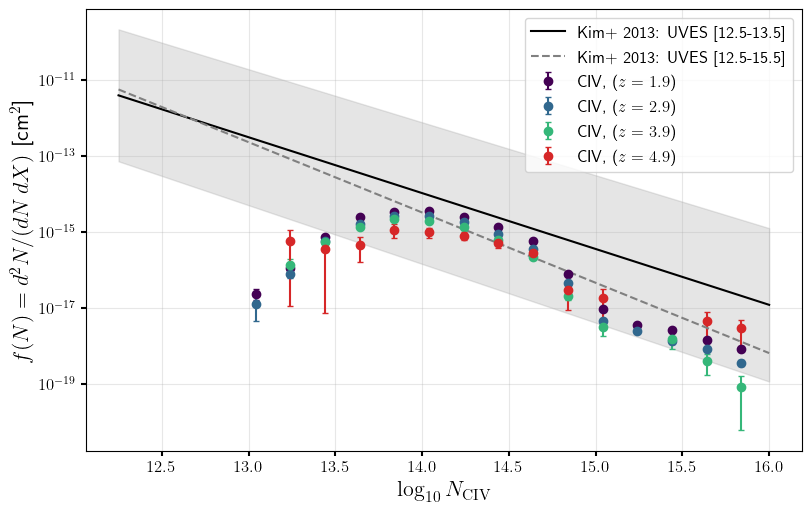

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)

plot_civ_cddf_slice_fN(out_cddf, zbin_index=0, label="CIV, ($z = {:.2g}$)".format(out_cddf["z_mid"][0]), prefer_boot=True, ax=ax, show=False, color=c_flatirons)
plot_civ_cddf_slice_fN(out_cddf, zbin_index=1, label="CIV, ($z = {:.2g}$)".format(out_cddf["z_mid"][1]), prefer_boot=True, ax=ax, show=False, color=c_midnight)
plot_civ_cddf_slice_fN(out_cddf, zbin_index=2, label="CIV, ($z = {:.2g}$)".format(out_cddf["z_mid"][2]), prefer_boot=True, ax=ax, show=False, color=c_skyline)
plot_civ_cddf_slice_fN(out_cddf, zbin_index=3, label="CIV, ($z = {:.2g}$)".format(out_cddf["z_mid"][3]), prefer_boot=True, ax=ax, show=False, color="C3")
# ax.set_ylim(1e-14, 1e-8)

lo, hi = civ_fit_valid_range("solid")
logN_m = np.linspace(lo, 16, 300)
f_m, f_lo, f_hi = cddf_civ_fit_logN(logN_m, which="solid", return_band=True, nsig=1.0)

ax.plot(logN_m, f_m, "k-", label="Kim+ 2013: UVES [12.5-13.5]")
ax.fill_between(logN_m, f_lo, f_hi, alpha=0.2, color="gray")

# another line
f_m2 = cddf_civ_fit_logN(logN_m, which="dotted", return_band=False)
ax.plot(logN_m, f_m2,  label="Kim+ 2013: UVES [12.5-15.5]", color="gray", ls="--")


plt.legend(fontsize=12, loc="upper right")
plt.show()


In [12]:
# lower P threshold
out_cddf_lowerP = compute_civ_cddf_fN_from_df(
    civ_det_data,
    zbins=zbins,
    logN_bins=logN_bins,
    p_thresh=0.85,       # hard threshold (no weighting)
    Omega_m=0.279,
    logNmin=12.54,
    logNmax=16.0,
    n_boot=200,          # bootstrap over sightlines
    rng=np.random.default_rng(1234),
    round_window_decimals=None,  # set to e.g. 6 if needed
)


/var/folders/sn/b7hd1bmd569cjwgmtww4mv440000gn/T/ipykernel_83783/3605645457.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


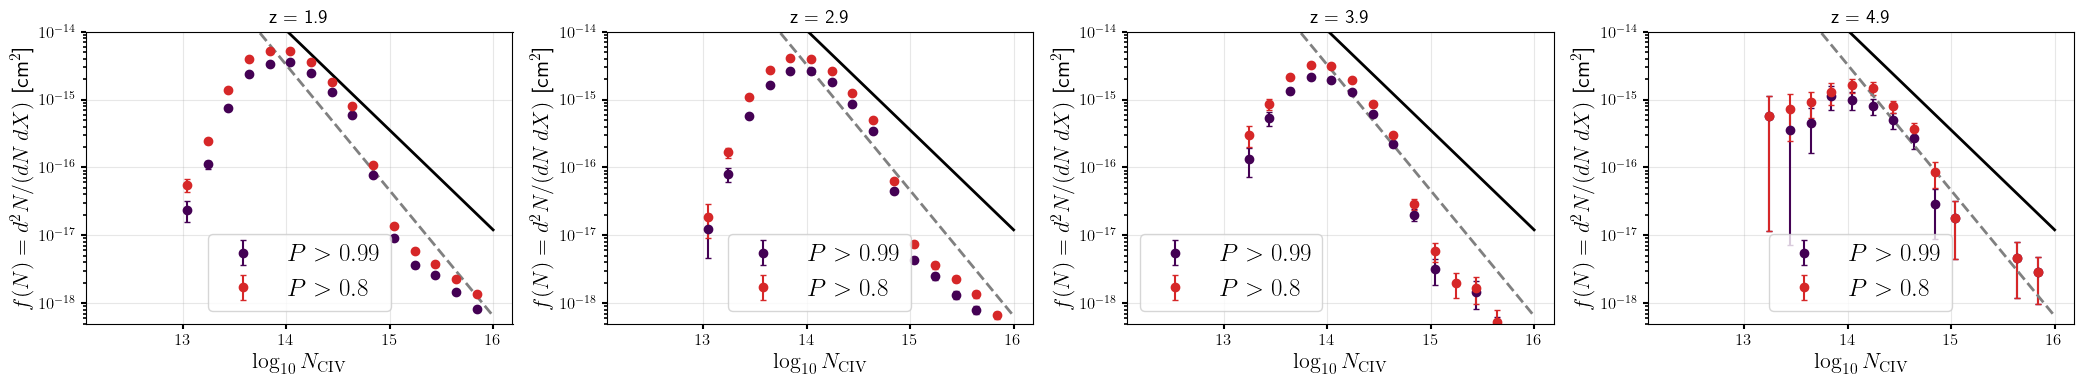

In [13]:
fig, ax = plt.subplots(1, 4, figsize=(21, 4), constrained_layout=True)

for i in range(4):
    plot_civ_cddf_slice_fN(out_cddf, zbin_index=i, label="$P > 0.99$".format(out_cddf["z_mid"][i]), prefer_boot=True, ax=ax[i], show=False, color=c_flatirons)
    plot_civ_cddf_slice_fN(out_cddf_lowerP, zbin_index=i, label="$P > 0.8$".format(out_cddf_lowerP["z_mid"][i]), prefer_boot=True, ax=ax[i], show=False, color="C3")

    # model
    ax[i].plot(logN_m, f_m, "k-", lw=2, label="Kim+ 2013: UVES [12.5-13.5]")
    # another line
    ax[i].plot(logN_m, f_m2, lw=2, label="Kim+ 2013: UVES [12.5-15.5]", color="gray", ls="--")

    ax[i].set_title("z = {:.2g}".format(out_cddf["z_mid"][i]))
    ax[i].set_ylim(5e-19, 1e-14)

fig.tight_layout()
# plot_civ_cddf_slice_fN(out_cddf_lowerP, zbin_index=1, label="CIV, ($z = {:.2g}$)".format(out_cddf_lowerP["z_mid"][1]), prefer_boot=True, ax=ax, show=False, color=c_midnight)
# plot_civ_cddf_slice_fN(out_cddf_lowerP, zbin_index=2, label="CIV, ($z = {:.2g}$)".format(out_cddf_lowerP["z_mid"][2]), prefer_boot=True, ax=ax, show=False, color=c_skyline)
# plot_civ_cddf_slice_fN(out_cddf_lowerP, zbin_index=3, label="CIV, ($z = {:.2g}$)".format(out_cddf_lowerP["z_mid"][3]), prefer_boot=True, ax=ax, show=False, color="C3")


## dN/dX

In [14]:
#!/usr/bin/env python3
# ============================================================
# CIV summary statistics:
#   - dN/dX in redshift bins (with p_CIV threshold)
#   - CDDF f(N) in Bird+ convention (optional, included here for completeness)
#
# Assumes a pandas DataFrame with columns:
#   Z        : absorber redshift
#   logN     : log10 column density (e.g. log10 N_CIV / cm^-2)
#   p_CIV    : detection probability (USED ONLY for thresholding)
#   z_min    : search window minimum for that sightline
#   z_max    : search window maximum for that sightline
#   test_ids : unique sightline id
#
# Critical:
#   ΔX must be computed ONCE PER SIGHTLINE (test_ids), not per absorber row.
# ============================================================

from __future__ import annotations
import numpy as np
import pandas as pd

# ----------------------------
# 1) Cosmology / absorption distance X(z)
# ----------------------------

def HubbleByH0(z, Omega_m=0.279):
    z = np.asarray(z, dtype=float)
    return np.sqrt(Omega_m * (1.0 + z) ** 3 + (1.0 - Omega_m))

def path_length_int(z, Omega_m=0.279):
    # dX/dz
    z = np.asarray(z, dtype=float)
    return (1.0 + z) ** 2 / HubbleByH0(z, Omega_m)

class AbsorptionDistance:
    """
    Compute X(z) = ∫ dX/dz dz using trapezoid rule on a grid.
    """
    def __init__(self, zmax, Omega_m=0.279, ngrid=40001):
        self.Omega_m = float(Omega_m)
        self.zgrid = np.linspace(0.0, float(zmax), int(ngrid))
        integrand = path_length_int(self.zgrid, Omega_m=self.Omega_m)

        dz = np.diff(self.zgrid)
        X = np.empty_like(self.zgrid)
        X[0] = 0.0
        X[1:] = np.cumsum(0.5 * (integrand[:-1] + integrand[1:]) * dz)
        self.Xgrid = X

    def X(self, z):
        z = np.asarray(z, dtype=float)
        return np.interp(z, self.zgrid, self.Xgrid)

    def deltaX(self, z1, z2):
        z1 = np.asarray(z1, dtype=float)
        z2 = np.asarray(z2, dtype=float)
        return self.X(z2) - self.X(z1)

def total_DeltaX_in_zbins(zbins, sight_zlo, sight_zhi, Xcalc):
    """
    ΔX_k = sum_i ∫_{W_i ∩ [z_k,z_{k+1}]} dX   over UNIQUE sightlines.
    """
    zbins = np.asarray(zbins, dtype=float)
    nb = len(zbins) - 1
    X_tot = np.zeros(nb, dtype=float)

    for k in range(nb):
        lo, hi = zbins[k], zbins[k + 1]
        o_lo = np.maximum(sight_zlo, lo)
        o_hi = np.minimum(sight_zhi, hi)
        m = o_hi > o_lo
        if np.any(m):
            X_tot[k] = np.sum(Xcalc.deltaX(o_lo[m], o_hi[m]))
    return X_tot


# ----------------------------
# 2) Build unique sightlines from DataFrame
# ----------------------------

def build_sightlines_from_df(
    df: pd.DataFrame,
    *,
    id_col="test_ids",
    zmin_col="z_min",
    zmax_col="z_max",
    round_window_decimals=None,
):
    """
    Returns:
      sight_ids (nsight,)
      sight_zlo (nsight,)
      sight_zhi (nsight,)
      id_to_idx dict
    """
    if round_window_decimals is not None:
        df = df.copy()
        df[zmin_col] = df[zmin_col].round(int(round_window_decimals))
        df[zmax_col] = df[zmax_col].round(int(round_window_decimals))

    sight = df[[id_col, zmin_col, zmax_col]].dropna().drop_duplicates(subset=[id_col])

    sight_ids = sight[id_col].to_numpy()
    sight_zlo = sight[zmin_col].to_numpy(dtype=float)
    sight_zhi = sight[zmax_col].to_numpy(dtype=float)

    good = np.isfinite(sight_zlo) & np.isfinite(sight_zhi) & (sight_zhi > sight_zlo)
    sight_ids = sight_ids[good]
    sight_zlo = sight_zlo[good]
    sight_zhi = sight_zhi[good]

    nsight = len(sight_ids)
    if nsight == 0:
        raise ValueError("No valid sightlines: require finite z_min/z_max and z_max > z_min.")

    id_to_idx = {sid: i for i, sid in enumerate(sight_ids)}
    return sight_ids, sight_zlo, sight_zhi, id_to_idx


# ----------------------------
# 3) dN/dX for CIV (p-threshold selection)
# ----------------------------

def compute_civ_dndx_from_df(
    civ_df: pd.DataFrame,
    *,
    zbins,
    id_col="test_ids",
    z_col="Z",
    logN_col="logN",
    p_col="p_CIV",
    zmin_col="z_min",
    zmax_col="z_max",
    p_thresh=0.99,
    Omega_m=0.279,
    logNmin=None,
    logNmax=None,
    n_boot=0,
    rng=None,
    round_window_decimals=None,
):
    """
    dN/dX in z-bins for CIV absorbers passing p_CIV >= p_thresh
    and optional logN cuts.

    Bootstrap:
      - resamples sightlines (test_ids) with replacement
      - counts and ΔX are both accumulated at the sightline level
    """
    zbins = np.asarray(zbins, dtype=float)
    z_mid = 0.5 * (zbins[:-1] + zbins[1:])
    nb = len(z_mid)

    # ---- Sightlines (unique test_ids) for ΔX
    sight_ids, sight_zlo, sight_zhi, id_to_idx = build_sightlines_from_df(
        civ_df,
        id_col=id_col,
        zmin_col=zmin_col,
        zmax_col=zmax_col,
        round_window_decimals=round_window_decimals,
    )
    nsight = len(sight_ids)

    # ---- Absorption distance + ΔX per z-bin (unique sightlines)
    Xcalc = AbsorptionDistance(zmax=float(np.max(sight_zhi)), Omega_m=Omega_m)
    X_tot = total_DeltaX_in_zbins(zbins, sight_zlo, sight_zhi, Xcalc)

    # ---- Filter absorbers by p-threshold (+ optional logN cuts)
    z_abs = civ_df[z_col].to_numpy(dtype=float)
    logN = civ_df[logN_col].to_numpy(dtype=float)
    p = civ_df[p_col].to_numpy(dtype=float)
    sid = civ_df[id_col].to_numpy()

    ok = np.isfinite(z_abs) & np.isfinite(logN) & np.isfinite(p)
    ok &= (p >= float(p_thresh))
    if logNmin is not None:
        ok &= (logN >= float(logNmin))
    if logNmax is not None:
        ok &= (logN <= float(logNmax))

    z_abs = z_abs[ok]
    sid = sid[ok]

    # Keep only absorbers whose sightline survived window validation
    keep = np.fromiter((s in id_to_idx for s in sid), dtype=bool, count=len(sid))
    z_abs = z_abs[keep]
    sid = sid[keep]

    # Counts per z-bin
    N_abs, _ = np.histogram(z_abs, bins=zbins)

    dndx = np.where(X_tot > 0, N_abs / X_tot, np.nan)
    err_pois = np.where(X_tot > 0, np.sqrt(N_abs) / X_tot, np.nan)

    # ---- Bootstrap over sightlines
    err_boot = None
    if n_boot and n_boot > 0:
        rng = np.random.default_rng() if rng is None else rng

        # assign each absorber to a z-bin and sightline index
        zbin = np.digitize(z_abs, zbins) - 1
        valid = (zbin >= 0) & (zbin < nb)
        zbin = zbin[valid]
        sid_v = sid[valid]
        sight_idx_abs = np.fromiter((id_to_idx[s] for s in sid_v), dtype=int, count=len(sid_v))

        # per-sightline counts in each zbin
        per_sight_counts = np.zeros((nsight, nb), dtype=int)
        np.add.at(per_sight_counts, (sight_idx_abs, zbin), 1)

        # per-sightline ΔX contributions in each zbin
        per_sight_X = np.zeros((nsight, nb), dtype=float)
        for k in range(nb):
            lo, hi = zbins[k], zbins[k + 1]
            o_lo = np.maximum(sight_zlo, lo)
            o_hi = np.minimum(sight_zhi, hi)
            m = o_hi > o_lo
            if np.any(m):
                per_sight_X[m, k] = Xcalc.deltaX(o_lo[m], o_hi[m])

        boot = np.empty((n_boot, nb), dtype=float)
        for b in range(n_boot):
            draw = rng.integers(0, nsight, size=nsight)
            Nb = per_sight_counts[draw].sum(axis=0)
            Xb = per_sight_X[draw].sum(axis=0)
            boot[b] = np.where(Xb > 0, Nb / Xb, np.nan)

        err_boot = np.nanstd(boot, axis=0, ddof=1)

    return {
        "z_mid": z_mid,
        "zbins": zbins,
        "dndx": dndx,
        "err_poisson": err_pois,
        "err_boot": err_boot,
        "N_abs": N_abs,
        "X_tot": X_tot,
        "nsight": nsight,
        "meta": {
            "Omega_m": float(Omega_m),
            "p_thresh": float(p_thresh),
            "logNmin": None if logNmin is None else float(logNmin),
            "logNmax": None if logNmax is None else float(logNmax),
        },
    }


# ----------------------------
# 4) Example usage
# ----------------------------
# if __name__ == "__main__":
#     # Replace this with your real DataFrame loading
#     civ_df = pd.DataFrame({
#         "Z":      [1.986074, 2.125348, 1.604026, 2.488643, 2.782393],
#         "logN":   [14.298362, 14.089500, 14.771092, 14.292976, 14.127203],
#         "p_CIV":  [1.0, 1.0, 1.0, 0.999929, 0.999116],
#         "z_max":  [2.148178, 2.148178, 1.822861, 2.792663, 2.792663],
#         "z_min":  [1.700753, 1.700753, 1.422705, 2.251595, 2.251595],
#         "test_ids":[62, 62, 69, 126, 126],
#     })

#     zbins = np.arange(1.4, 3.2 + 1e-9, 0.2)

#     out = compute_civ_dndx_from_df(
#         civ_df,
#         zbins=zbins,
#         p_thresh=0.99,
#         Omega_m=0.279,
#         logNmin=None,
#         logNmax=None,
#         n_boot=200,
#         rng=np.random.default_rng(1234),
#         round_window_decimals=None,  # set to 6 if needed
#     )

#     print("nsight =", out["nsight"])
#     print("z_mid =", out["z_mid"])
#     print("dN/dX =", out["dndx"])
#     print("Poisson err =", out["err_poisson"])
#     print("Bootstrap err =", out["err_boot"])

In [15]:
out_dndx = compute_civ_dndx_from_df(
    civ_det_data,
    zbins=zbins,
    p_thresh=0.99,
    Omega_m=0.279,
    logNmin=13,
    logNmax=15,
    n_boot=200,
    rng=np.random.default_rng(1234),
    round_window_decimals=None,  # set to 6 if needed
)

print("nsight =", out_dndx["nsight"])
print("z_mid =", out_dndx["z_mid"])
print("dN/dX =", out_dndx["dndx"])
print("Poisson err =", out_dndx["err_poisson"])
print("Bootstrap err =", out_dndx["err_boot"])

nsight = 69713
z_mid = [1.9 2.9 3.9 4.9]
dN/dX = [0.86868458 0.60294058 0.4427233  0.29959445]
Poisson err = [0.00340996 0.00438807 0.01093894 0.03716012]
Bootstrap err = [0.00408699 0.00511606 0.01178724 0.03671807]


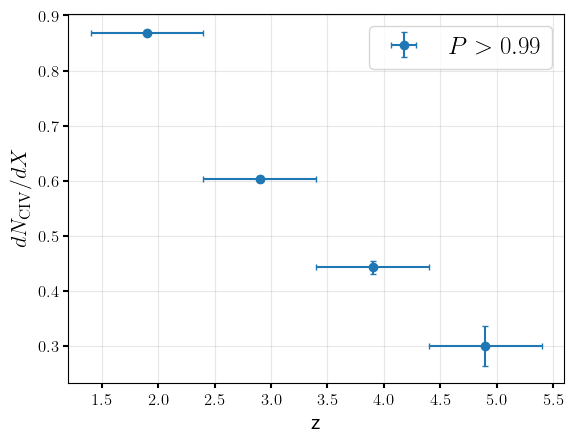

<Axes: xlabel='z', ylabel='$dN_{\\rm CIV}/dX$'>

In [16]:
plot_civ_dndx(out_dndx, label="$P > 0.99$", prefer_boot=True)